In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import pipeline.src.python.config as cfg
import pandas as pd
import numpy as np
pd.set_option('display.max_colwidth', None)

In [3]:
import networkx as nx

In [4]:
MAGAZINE_1 = 'science_news'
DATASET_TEXT_FEATURE = (
    "text"  # In the dataset file, the column name that contains the text data
)
cfg_dict_1 = cfg.MAGAZINE_CONFIG[MAGAZINE_1]

In [5]:
MAGAZINE_2 = 'scopus'
cfg_dict_2 = cfg.MAGAZINE_CONFIG[MAGAZINE_2]

## Loading models

In [6]:
from bertopic import BERTopic

model_path = cfg.MODELS_FOLDER / f'{MAGAZINE_1}/model_0.309.safetensors'
model_1 = BERTopic.load(model_path, 
                      embedding_model=cfg.EMBEDDING_MODEL
                      )

/home/banfi/.uve/cuda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
model_path_2 = cfg.MODELS_FOLDER / f'{MAGAZINE_2}/model_0.343.safetensors'

model_2 = BERTopic.load(model_path_2,
                        cfg.EMBEDDING_MODEL
                        )


## Loading data

In [8]:
data = np.load(cfg_dict_1['OUTPUT_PATH'],allow_pickle=True) 

ids = data['id']
texts = data['text'] 
embeddings = data['embedding'] 
documents = data['clean_text']

In [9]:
data_2 = np.load(cfg_dict_2['OUTPUT_PATH'],allow_pickle=True) 

ids_2 = data_2['id']
texts_2 = data_2['text'] 
embeddings_2 = data_2['embedding'] 
documents_2 = data_2['clean_text']

## Evaluate metrics

### Model 1 -> Model 2

In [10]:
model_2_topic_labels = { idx:topic for idx, topic in enumerate(model_2.custom_labels_,start=-1) }

In [11]:
from pipeline.src.python.btm import BTM

models_metrics = BTM(model_1=model_1,model_2=model_2,ids_1=ids,texts_1=texts,embeddings_1=embeddings,texts_2=texts_2,embeddings_2=embeddings_2,model_1_name=MAGAZINE_1.title(),model_2_name=MAGAZINE_2.title())

2026-02-05 12:44:36,864 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


2026-02-05 12:44:38,221 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


Threshold:0.38246655464172363


In [12]:
models_metrics.evaluate_metrics()

In [13]:
models_metrics.print_corpus_metrics()

Evaluation: Science_News -> Scopus
Corpus Closeness: 0.7346563033890575
Evaluation: Science_News -> Scopus
Corpus Uniqueness: 0.2653436966109427
Evaluation: Science_News -> Scopus
Corpus Alignment: 0.30646637973611784


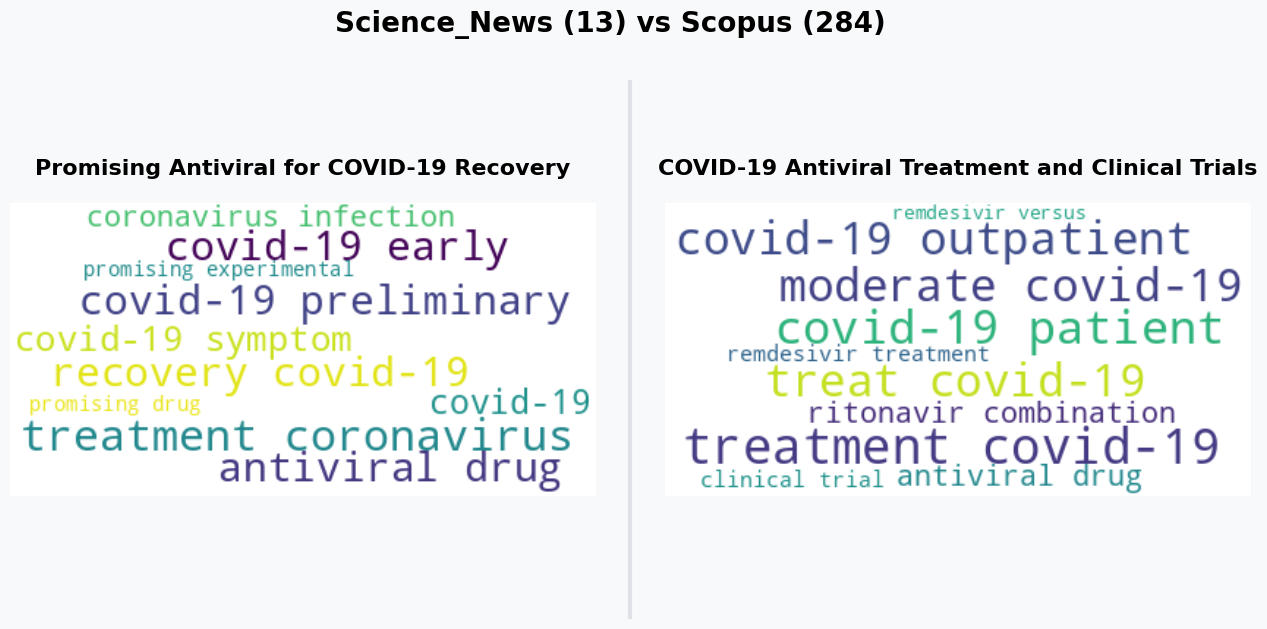

In [28]:
models_metrics.compare_wordcloud_topics(13,284)

## Graph experiments

In [18]:
G = nx.Graph(description='Model1 -> Model2')


In [16]:
topic_count_1 = model_1.get_topic_freq()['Count'].to_list()
topic_labels_1 = model_1.custom_labels_

topic_count_2 = model_2.get_topic_freq()['Count'].to_list()
topic_labels_2 = model_2.custom_labels_

for idx_node in range(1,len(model_1.custom_labels_)):
    G.add_node( topic_labels_1[idx_node],group = 'Native', color = 'red', degree=topic_count_1[idx_node])

for idx_node in range(1,len(model_2.custom_labels_)):
    G.add_node( topic_labels_2[idx_node],group = 'Cross', color = 'green', degree=topic_count_2[idx_node])
    

In [62]:
for n, attr in G.nodes(data=True):
    print(n, attr)

Champions League Team Performance {'group': 'Native', 'color': 'red', 'degree': 2621}
Pandemic Response in Australia {'group': 'Native', 'color': 'red', 'degree': 1192}
Biden vs. Trump Campaign Rivalry {'group': 'Native', 'color': 'red', 'degree': 882}
Ebola Outbreak Response {'group': 'Native', 'color': 'red', 'degree': 726}
Chinese Pandemic Authority Response {'group': 'Native', 'color': 'red', 'degree': 707}
Retail Sale Decline Trends {'group': 'Native', 'color': 'red', 'degree': 693}
NHS Staffing Challenge {'group': 'Native', 'color': 'red', 'degree': 661}
Genetic Progress and Modification {'group': 'Native', 'color': 'red', 'degree': 625}
Bird Flu Outbreak in Poultry Farms {'group': 'Native', 'color': 'red', 'degree': 592}
Connection in Isolation {'group': 'Native', 'color': 'red', 'degree': 590}
Police-Protester Tensions {'group': 'Native', 'color': 'red', 'degree': 567}
Travel Quarantine Rules in England {'group': 'Native', 'color': 'red', 'degree': 527}
Johnson Leadership Era {

In [17]:
for row in models_metrics.get_topic_closeness()[['Topic_label_model_1','Topic_label_model_2','Closeness']].itertuples():
    G.add_edge(row.Topic_label_model_1,row.Topic_label_model_2,weight=row.Closeness)


In [33]:
import networkx as nx
from pyvis.network import Network


def compute_positions_left_right(G_sub):
    """
    Calcola posizioni per i nodi separando Native a sinistra e Cross a destra.
    
    Parametri:
    ----------
    G_sub : networkx.Graph
        Subgrafo con i nodi da posizionare
        
    Returns:
    --------
    dict : Dizionario {node_id: {"x": x_pos, "y": y_pos}}
    """
    if G_sub.number_of_nodes() == 0:
        return {}
    
    # Separa i nodi per gruppo
    native_nodes = [n for n in G_sub.nodes() if G_sub.nodes[n].get("group") == "Native"]
    cross_nodes = [n for n in G_sub.nodes() if G_sub.nodes[n].get("group") == "Cross"]
    other_nodes = [n for n in G_sub.nodes() if G_sub.nodes[n].get("group") not in ["Native", "Cross"]]
    
    # Crea subgrafi per ogni gruppo
    G_native = G_sub.subgraph(native_nodes).copy() if native_nodes else nx.Graph()
    G_cross = G_sub.subgraph(cross_nodes).copy() if cross_nodes else nx.Graph()
    G_other = G_sub.subgraph(other_nodes).copy() if other_nodes else nx.Graph()
    
    pos = {}

    fixed_x_native = -900
    fixed_y_native = 0
    y_increment = 100

    # Layout per Native (sinistra) - coordinate più ampie
    if G_native.number_of_nodes() > 0:
        pos_native = nx.spring_layout(G_native, seed=42, k=2.0, iterations=150)
        for n, (x, y) in pos_native.items():
            # Moltiplico per valori più grandi e sposto decisamente a sinistra
            #pos[n] = {"x": (x * 400) - 600, "y": y * 800}
            fixed_y_native += y_increment
            pos[n] = {"x": fixed_x_native, "y": fixed_y_native}
    
    # Layout per Cross (destra) - coordinate più ampie
    if G_cross.number_of_nodes() > 0:
        pos_cross = nx.spring_layout(G_cross, seed=42, k=2.0, iterations=150)
        for n, (x, y) in pos_cross.items():
            # Moltiplico per valori più grandi e sposto decisamente a destra
            pos[n] = {"x": (x * 400) + 600, "y": y * 800}
    
    # Layout per altri nodi (centro)
    if G_other.number_of_nodes() > 0:
        pos_other = nx.spring_layout(G_other, seed=42, k=2.0, iterations=150)
        for n, (x, y) in pos_other.items():
            pos[n] = {"x": x * 400, "y": y * 800}  # Centro
    
    return pos


def scale(v, vmin, vmax, out_min, out_max):
    """Scala un valore da un range a un altro."""
    if vmax == vmin:
        return (out_min + out_max) / 2
    return out_min + (v - vmin) * (out_max - out_min) / (vmax - vmin)


def export_graph_to_html(
    G, 
    filename="graph.html",
    min_weight=0.0,
    hide_isolates=True,
    height="800px",
    width="100%",
    physics_enabled=False,
    show_buttons=True
):
    """
    Esporta un grafo NetworkX in un file HTML interattivo standalone.
    
    Parametri:
    ----------
    G : networkx.Graph
        Il grafo da esportare
    filename : str
        Nome del file HTML di output (default: "graph.html")
    min_weight : float
        Soglia minima per mostrare gli archi (default: 0.0)
    hide_isolates : bool
        Se True, nasconde i nodi senza archi dopo il filtro (default: True)
    height : str
        Altezza del grafo (default: "800px")
    width : str
        Larghezza del grafo (default: "100%")
    physics_enabled : bool
        Se True, abilita la simulazione fisica (default: True)
    show_buttons : bool
        Se True, mostra i controlli interattivi (default: True)
    
    Returns:
    --------
    dict : Statistiche del grafo esportato
    """
    
    # 1) FILTRA GLI ARCHI in base al peso minimo
    edges_kept = []
    for u, v, a in G.edges(data=True):
        w = float(a.get("weight", 0.0))
        if w >= min_weight:
            edges_kept.append((u, v, w))
    
    # 2) DETERMINA I NODI DA MANTENERE
    if hide_isolates:
        # Solo nodi che hanno almeno un arco
        nodes_kept = set()
        for u, v, _ in edges_kept:
            nodes_kept.add(u)
            nodes_kept.add(v)
    else:
        # Tutti i nodi del grafo
        nodes_kept = set(G.nodes())
    
    # 3) CREA IL SUBGRAFO
    G_sub = G.subgraph(nodes_kept).copy()
    
    # 4) CALCOLA RANGE PER SCALING
    if G_sub.number_of_nodes() > 0:
        deg_vals = [G_sub.nodes[n].get("degree", G_sub.degree(n)) for n in G_sub.nodes()]
        dmin, dmax = min(deg_vals), max(deg_vals)
    else:
        dmin, dmax = 0, 1
    
    if edges_kept:
        w_vals = [w for _, _, w in edges_kept]
        wmin, wmax = min(w_vals), max(w_vals)
    else:
        wmin, wmax = 0, 1
    
    # 5) CREA LA RETE PYVIS
    net = Network(
        height=height,
        width=width,
        directed=True,
        notebook=False,
        cdn_resources='remote',
        bgcolor='#ffffff',
        font_color='black'
    )
    
    # Configura la fisica direttamente nelle opzioni della rete
    if physics_enabled:
        net.barnes_hut(
            gravity=-3000,  # Ridotto per meno attrazione al centro
            central_gravity=0.1,  # Ridotto per permettere la separazione
            spring_length=250,  # Aumentato per più spazio
            spring_strength=0.01,  # Ridotto per meno rigidità
            damping=0.15,  # Aumentato per stabilizzare prima
            overlap=0.2  # Aumentato per evitare sovrapposizioni
        )
    
    # 6) CALCOLA LE POSIZIONI CON SEPARAZIONE LEFT/RIGHT
    positions = compute_positions_left_right(G_sub)
    
    # 7) AGGIUNGI I NODI CON POSIZIONI
    for n in G_sub.nodes():
        a = G_sub.nodes[n]
        degree = a.get("degree", G_sub.degree(n))
        
        # Scala la dimensione del nodo in base al grado
        size = scale(float(degree), float(dmin), float(dmax), 15, 50)
        
        color = a.get("color", "#999999")
        group = a.get("group", "UNKNOWN")
        
        # Crea il titolo (tooltip) con informazioni dettagliate
        title = f"<b>{n}</b><br>Gruppo: {group}<br>Grado: {degree}"
        
        # Ottieni posizione
        pos = positions.get(n, {"x": 0, "y": 0})
        
        net.add_node(
            n,
            label=str(n),
            value=size,  # Pyvis usa 'value' per la dimensione
            color=color,
            group=group,
            title=title,
            x=pos["x"],
            y=pos["y"],
            physics=physics_enabled  # Se physics=False, la posizione è fissa
        )
    
    # 8) AGGIUNGI GLI ARCHI
    for u, v, w in edges_kept:
        if u not in G_sub or v not in G_sub:
            continue
        
        # Scala lo spessore dell'arco in base al peso
        width = scale(float(w), float(wmin), float(wmax), 1.0, 8.0)
        
        # Tooltip per l'arco
        title = f"{u} ↔ {v}<br>Peso: {w:.3f}"
        
        net.add_edge(
            u, v,
            value=width,
            title=title,
            weight=w
        )
    
    # 9) MOSTRA/NASCONDI PULSANTI DI CONTROLLO
    if show_buttons:
        try:
            net.show_buttons(filter_=['physics'])
        except:
            pass  # Ignora se non supportato
    
    if not physics_enabled:
        net.toggle_physics(False)
    
    # 10) SALVA IL FILE
    net.save_graph(filename)
    
    # 11) STATISTICHE
    stats = {
        "filename": filename,
        "total_nodes": G.number_of_nodes(),
        "total_edges": G.number_of_edges(),
        "displayed_nodes": G_sub.number_of_nodes(),
        "displayed_edges": len(edges_kept),
        "min_weight_threshold": min_weight,
        "hide_isolates": hide_isolates
    }
    
    print(f"\n{'='*60}")
    print(f"✓ Grafo esportato con successo!")
    print(f"{'='*60}")
    print(f"📁 File salvato: {filename}")
    print(f"📊 Statistiche:")
    print(f"   • Nodi totali nel grafo: {stats['total_nodes']}")
    print(f"   • Archi totali nel grafo: {stats['total_edges']}")
    print(f"   • Nodi visualizzati: {stats['displayed_nodes']}")
    print(f"   • Archi visualizzati: {stats['displayed_edges']}")
    print(f"   • Soglia peso minimo: {stats['min_weight_threshold']:.3f}")
    print(f"   • Nascondi isolati: {stats['hide_isolates']}")
    print(f"{'='*60}\n")
    
    return stats


def export_multiple_versions(G, base_filename="graph", thresholds=[0.0, 0.3, 0.5, 0.7]):
    """
    Esporta multiple versioni del grafo con diverse soglie di peso.
    
    Parametri:
    ----------
    G : networkx.Graph
        Il grafo da esportare
    base_filename : str
        Nome base per i file (default: "graph")
    thresholds : list
        Lista di soglie di peso da usare (default: [0.0, 0.3, 0.5, 0.7])
    
    Returns:
    --------
    list : Lista di statistiche per ogni versione esportata
    """
    all_stats = []
    
    for threshold in thresholds:
        filename = f"{base_filename}_threshold_{threshold:.2f}.html"
        stats = export_graph_to_html(
            G,
            filename=filename,
            min_weight=threshold,
            hide_isolates=True
        )
        all_stats.append(stats)
    
    print(f"\n✓ Esportate {len(thresholds)} versioni del grafo!")
    return all_stats


# ESEMPIO D'USO (decommentare per testare)
if __name__ == "__main__":
    # Crea un grafo di esempio

    filtered = True

    G = nx.Graph(description='Model1 -> Model2')
    
    # Aggiungi attributi casuali per testare
    topic_count_1 = model_1.get_topic_freq()['Count'].to_list()
    topic_labels_1 = model_1.custom_labels_

    topic_count_2 = model_2.get_topic_freq()['Count'].to_list()
    topic_labels_2 = model_2.custom_labels_

    for idx_node in range(1,len(model_1.custom_labels_)):
        G.add_node( topic_labels_1[idx_node],group = 'Native', color = 'red', degree=topic_count_1[idx_node])

    for idx_node in range(1,len(model_2.custom_labels_)):
        G.add_node( topic_labels_2[idx_node],group = 'Cross', color = 'green', degree=topic_count_2[idx_node])

    topics_to_explore = models_metrics.get_topic_closeness()[['Topic_model_1','Topic_model_2','Topic_label_model_1','Topic_label_model_2','Closeness']]
    
    if filtered == True:
        topics_to_explore = topics_to_explore[ topics_to_explore[ 'Topic_model_1'].isin([105,18,24])]
    
    for row in topics_to_explore.itertuples():
        G.add_edge(row.Topic_label_model_1,row.Topic_label_model_2,weight=row.Closeness)
    
    # Esporta una singola versione
    export_graph_to_html(
        G,
        filename="esempio_grafo.html",
        min_weight=0.0,
        hide_isolates=True,
        show_buttons=True
    )
    
    # Oppure esporta versioni multiple
    # export_multiple_versions(G, base_filename="esempio", thresholds=[0.0, 0.2, 0.5, 0.8])


✓ Grafo esportato con successo!
📁 File salvato: esempio_grafo.html
📊 Statistiche:
   • Nodi totali nel grafo: 604
   • Archi totali nel grafo: 13
   • Nodi visualizzati: 14
   • Archi visualizzati: 13
   • Soglia peso minimo: 0.000
   • Nascondi isolati: True



## End graph experiments

In [14]:
models_metrics.print_corpus_metrics()

Evaluation: Science_News -> Scopus
Corpus Closeness: 0.7346563033890575
Evaluation: Science_News -> Scopus
Corpus Uniqueness: 0.2653436966109427
Evaluation: Science_News -> Scopus
Corpus Alignment: 0.30646637973611784


In [29]:
models_metrics.print_weighted_corpus_metrics()

Evaluation: Science_News -> Scopus
Corpus Closeness: 0.7913043478260869
Evaluation: Science_News -> Scopus
Corpus Uniqueness: 0.20869565217391303
Evaluation: Science_News -> Scopus
Corpus Alignment: 0.2858695652173913


In [16]:
a = models_metrics.get_topic_closeness().sort_values(by='Topic Closeness',ascending=False)

In [17]:
a.to_csv(f'./BTM_metrics/{MAGAZINE_1.title()}_vs_{MAGAZINE_2.title()}_closeness.csv',sep='ç',encoding='utf-8')

In [18]:
models_metrics.get_topic_alignment()

,Science_News Topic Label,Science_News Topic Id,Alignment
0,Covid-19 Vaccine Availability and Effectiveness,0,0.264706
1,HIV Treatment and Therapy,1,0.390805
2,Flu Virus Spread Patterns,2,0.246914
3,Covid-19 Pandemic Mitigation Strategies,3,0.208333
4,Zika Outbreak and Mosquito Spread,4,0.180328
5,Antibiotic Resistance Crisis,5,0.227273
6,Bacterial Infection Mechanisms,6,0.162791
7,SARS-CoV-2 Origin and Evolution,7,0.263158
8,Chronic COVID Symptom Persistence,8,0.400000
9,Ebola Vaccine Development,9,0.257143


In [20]:
a[ a['Topic Closeness'] >= 0.5 ].head(10)

,The_Guardian Topic Id,Scopus Topic Id,The_Guardian Topic Label,Scopus Topic Label,Total Couple matches,Topic Corpus Occurrences,Topic Closeness
95,105,14,Mpox Outbreak in Africa,Mpox Outbreak Transmission,99,104,0.951923
56,72,75,Zika Outbreak and Risk,Zika Virus Outbreaks,133,149,0.892617
142,138,115,Covid Contact Tracing App,Covid-19 Contact Tracing App,65,73,0.890411
152,149,105,Antibiotic Misuse in Farming,Animal Antimicrobial Use,61,70,0.871429
52,59,1,Tuberculosis Treatment Challenges,Tuberculosis Resistance and Control,150,175,0.857143
29,38,198,Vaccine Equity and Access,Childhood Vaccination Coverage,217,256,0.847656
68,64,6,African Omicron Variant Spread,SARS-CoV-2 Genomic Evolution,125,161,0.776398
132,117,119,Pandemic Preparedness Failure,Healthcare System Preparedness for Pandemics,70,92,0.760870
55,57,42,Polio Eradication Crisis in Pakistan and Afghanistan,Poliovirus Surveillance and Transmission,134,180,0.744444
84,71,83,Measles Vaccination Effort,Measles and Rubella Control,111,151,0.735099


In [19]:
from great_tables import GT, style, loc

df = a[ a['Topic Closeness'] >= 0.5 ].head(30).tail(15)
GT(df)\
    .tab_style(
      style=[
          style.fill(color="#2c3e50"),
          style.text(color="white", weight="bold", align="center",v_align="middle")
      ],
      locations=loc.column_labels()
  )\
  .tab_style(
      style=[
          style.text(size="18px", weight="bold"),
          style.fill(color="#ecf0f1")
      ],
      locations=loc.title()
  )\
  .tab_style(
      style=style.text(weight="bold", align="center"),
      locations=loc.body(columns=[f"{MAGAZINE_1.title()} Topic Label", f"{MAGAZINE_2.title()} Topic Label", "Topic Closeness"])
  )\
  .tab_style(
      style=style.text(align="center"),
      locations=loc.body(columns=[f"{MAGAZINE_1.title()} Topic Id", f"{MAGAZINE_2.title()} Topic Id","Total Couple matches","Topic Corpus Occurrences"])
  )\
  .tab_style(
      style=style.text(align="center"),
      locations=loc.column_labels()
  ).fmt_number(columns=["Topic Closeness"], decimals=4)\
    .tab_style(
      style=style.fill(color="#4a9ed6"),
      locations=loc.body(rows=[i for i in range(len(df)) if i % 2 == 0])
  )\
  .tab_style(
      style=style.fill(color="white"),
      locations=loc.body(rows=[i for i in range(len(df)) if i % 2 != 0])
  )

Science_News Topic Id,Scopus Topic Id,Science_News Topic Label,Scopus Topic Label,Total Couple matches,Topic Corpus Occurrences,Topic Closeness
21,83,Global Outbreak Update,Measles and Rubella Control,12,14,0.8571
10,75,Zika Virus and Microcephaly,Zika Virus Outbreaks,19,26,0.7308
20,216,Coronavirus Outbreak Spread,Coronavirus Disease Outbreak,11,16,0.6875
16,79,Ebola Outbreak Spread,Ebola Outbreak Response in Africa,11,19,0.5789
25,144,Male Circumcision and HIV Prevalence,HIV Risk and Transmission Status,6,11,0.5455
13,284,Promising Antiviral for COVID-19 Recovery,COVID-19 Antiviral Treatment and Clinical Trials,11,22,0.5000


In [20]:
b = models_metrics.get_topic_uniqueness().sort_values(by='Topic Uniqueness',ascending=False)

In [21]:
b.to_csv(f'./BTM_metrics/{MAGAZINE_1.title()}_vs_{MAGAZINE_2.title()}_uniqueness.csv',sep='ç',encoding='utf-8')

In [22]:
from great_tables import GT, style, loc

df = b[ b['Topic Uniqueness'] >= 0.5 ].head(30).tail(10)
GT(df)\
    .tab_style(
      style=[
          style.fill(color="#3f2c50"),
          style.text(color="white", weight="bold", align="center",v_align="middle")
      ],
      locations=loc.column_labels()
  )\
  .tab_style(
      style=[
          style.text(size="18px", weight="bold"),
          style.fill(color="#ecf0f1")
      ],
      locations=loc.title()
  )\
  .tab_style(
      style=style.text(weight="bold", align="center"),
      locations=loc.body(columns=[f"{MAGAZINE_1.title()} Topic Label", "Topic Uniqueness"])
  )\
  .tab_style(
      style=style.text(align="center"),
      locations=loc.body(columns=[f"{MAGAZINE_1.title()} Topic Id"])
  )\
  .tab_style(
      style=style.text(align="center"),
      locations=loc.column_labels()
  ).fmt_number(columns=["Topic Uniqueness"], decimals=4)\
    .tab_style(
      style=[style.fill(color="#584ad6"),style.text(color='white')],
      locations=loc.body(rows=[i for i in range(len(df)) if i % 2 == 0])
  )\
  .tab_style(
      style=style.fill(color="white"),
      locations=loc.body(rows=[i for i in range(len(df)) if i % 2 != 0])
  )

Science_News Topic Label,Science_News Topic Id,Topic Uniqueness
Future Impact of Equitable Security Advancement,12,0.9231
Imaging Advancements in Cellular Biology,14,0.8571
Synthetic Microbes for Sustainable Production,17,0.7368
HIV Vaccine Trial Challenge,27,0.7000
Genetic Mosquito Control,18,0.6111


In [34]:
len( b[ b['Topic Uniqueness']>= 0.5])

128

### Cambiare metrica per alignment?

In [18]:
alignment_totale = models_metrics.get_topic_alignment()['Alignment'].sum()

In [19]:
models_metrics.get_topic_closeness()['Topic_model_1'].sort_values().unique()

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 101, 102, 103, 104, 105,
       106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118,
       119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131,
       132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144,
       145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157,
       158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170,
       171, 172, 173, 174, 175, 176, 177])

In [40]:
alignment_totale / models_metrics.n_topics_model_1

np.float64(0.2676525235567512)

In [41]:
alignment_totale / len(models_metrics.get_topic_alignment())

np.float64(0.27221478248101394)

### Model 2 -> Model 1

In [30]:
inverse_models_metrics = BTM(model_1=model_2,model_2=model_1,ids_1=ids_2,texts_1=texts_2,embeddings_1=embeddings_2,texts_2=texts,embeddings_2=embeddings,model_1_name=MAGAZINE_2.title(),model_2_name=MAGAZINE_1.title())

2026-02-05 12:59:45,592 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2026-02-05 12:59:45,619 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


Threshold:0.3790895342826843


In [31]:
inverse_models_metrics.evaluate_metrics()

In [32]:
inverse_models_metrics.print_corpus_metrics()

Evaluation: Scopus -> Science_News
Corpus Closeness: 0.2592611035011189
Evaluation: Scopus -> Science_News
Corpus Uniqueness: 0.740738896498881
Evaluation: Scopus -> Science_News
Corpus Alignment: 0.1905466894441702


In [33]:
inverse_models_metrics.print_weighted_corpus_metrics()

Evaluation: Scopus -> Science_News
Corpus Closeness: 0.2523301966730589
Evaluation: Scopus -> Science_News
Corpus Uniqueness: 0.7476698033269411
Evaluation: Scopus -> Science_News
Corpus Alignment: 0.18605895732060831


In [34]:
x = inverse_models_metrics.get_topic_closeness().sort_values(by='Topic Closeness',ascending=False)

In [35]:
x.to_csv(f'./BTM_metrics/{MAGAZINE_2.title()}_vs_{MAGAZINE_1.title()}_closeness.csv',sep='ç',encoding='utf-8')

In [39]:
from great_tables import GT, style, loc

df = x[ x['Topic Closeness'] >= 0.5 ].head(20).tail(10)
GT(df)\
    .tab_style(
      style=[
          style.fill(color="#2c3e50"),
          style.text(color="white", weight="bold", align="center",v_align="middle")
      ],
      locations=loc.column_labels()
  )\
  .tab_style(
      style=[
          style.text(size="18px", weight="bold"),
          style.fill(color="#ecf0f1")
      ],
      locations=loc.title()
  )\
  .tab_style(
      style=style.text(weight="bold", align="center"),
      locations=loc.body(columns=[f"{MAGAZINE_2.title()} Topic Label", f"{MAGAZINE_1.title()} Topic Label", "Topic Closeness"])
  )\
  .tab_style(
      style=style.text(align="center"),
      locations=loc.body(columns=[f"{MAGAZINE_2.title()} Topic Id", f"{MAGAZINE_1.title()} Topic Id","Total Couple matches","Topic Corpus Occurrences"])
  )\
  .tab_style(
      style=style.text(align="center"),
      locations=loc.column_labels()
  ).fmt_number(columns=["Topic Closeness"], decimals=4)\
    .tab_style(
      style=style.fill(color="#4a9ed6"),
      locations=loc.body(rows=[i for i in range(len(df)) if i % 2 == 0])
  )\
  .tab_style(
      style=style.fill(color="white"),
      locations=loc.body(rows=[i for i in range(len(df)) if i % 2 != 0])
  )

Scopus Topic Id,Science_News Topic Id,Scopus Topic Label,Science_News Topic Label,Total Couple matches,Topic Corpus Occurrences,Topic Closeness
7,19,Wastewater Surveillance for Cov-2 Detection,Disease Outbreak Tracking Initiative,1670,1884,0.8864
179,2,Avian Influenza H7N9 Human Infections,Flu Virus Spread Patterns,218,247,0.8826
191,11,SARS-CoV-2 Epitope Vaccine Immunity,Immune Response in Viral Infections,202,234,0.8632
79,16,Ebola Outbreak Response in Africa,Ebola Outbreak Spread,418,488,0.8566
216,20,Coronavirus Disease Outbreak,Coronavirus Outbreak Spread,176,206,0.8544
65,2,Swine Influenza Viruses and Transmission,Flu Virus Spread Patterns,491,575,0.8539
9,2,HPAI Outbreak and Pathogenicity,Flu Virus Spread Patterns,1427,1685,0.8469
320,0,Vaccine Attitudes and Uptake,Covid-19 Vaccine Availability and Effectiveness,104,123,0.8455
116,3,SARS-CoV-2 Seroprevalence and Population Exposure,Covid-19 Pandemic Mitigation Strategies,298,358,0.8324
284,13,COVID-19 Antiviral Treatment and Clinical Trials,Promising Antiviral for COVID-19 Recovery,124,149,0.8322


In [37]:
len( x[ x['Topic Closeness'] >= 0.5 ] )

54

In [60]:
y = inverse_models_metrics.get_topic_uniqueness().sort_values(by='Topic Uniqueness',ascending=False)

In [65]:
from great_tables import GT, style, loc

df = y[ y['Topic Uniqueness'] >= 0.5 ].head(30).tail(10)
GT(df)\
    .tab_style(
      style=[
          style.fill(color="#3f2c50"),
          style.text(color="white", weight="bold", align="center",v_align="middle")
      ],
      locations=loc.column_labels()
  )\
  .tab_style(
      style=[
          style.text(size="18px", weight="bold"),
          style.fill(color="#ecf0f1")
      ],
      locations=loc.title()
  )\
  .tab_style(
      style=style.text(weight="bold", align="center"),
      locations=loc.body(columns=[f"{MAGAZINE_2.title()} Topic Label", "Topic Uniqueness"])
  )\
  .tab_style(
      style=style.text(align="center"),
      locations=loc.body(columns=[f"{MAGAZINE_2.title()} Topic Id"])
  )\
  .tab_style(
      style=style.text(align="center"),
      locations=loc.column_labels()
  ).fmt_number(columns=["Topic Uniqueness"], decimals=4)\
    .tab_style(
      style=[style.fill(color="#584ad6"),style.text(color='white')],
      locations=loc.body(rows=[i for i in range(len(df)) if i % 2 == 0])
  )\
  .tab_style(
      style=style.fill(color="white"),
      locations=loc.body(rows=[i for i in range(len(df)) if i % 2 != 0])
  )

Scopus Topic Label,Scopus Topic Id,Topic Uniqueness
Pfas in Municipal Biosolids and Sludge Treatment,59,0.9731
Early Warning System for Banking Risks,80,0.9729
Antimicrobial Food Packaging Films,346,0.9727
Recombinant Vaccinia Virus Particle,265,0.9689
Zoonotic Angiostrongylus Infections and Neuroangiostrongyliasis,377,0.9684
CMV Treatment and Prevention,274,0.9679
PacBio Long Read Genome Assembly,214,0.9663
HSV-1 Replication and Infection,136,0.9660
"resistantThe label should be something like ""Daptomycin Use in",220,0.9650
Carbapenem and β-Lactam Antibiotic Susceptibility Trends,412,0.9643


In [68]:
y.to_csv(f'./BTM_metrics/{MAGAZINE_2.title()}_vs_{MAGAZINE_1.title()}_uniqueness.csv',sep='ç',encoding='utf-8')

In [63]:
len( y[ y['Topic Uniqueness'] >= 0.5 ] )

253

In [30]:
inverse_models_metrics.topic_alignment.sort_values(by='Alignment',ascending=False)

,Topic_model_1,Topic_label_model_1,Count,Alignment,Weigth
195,196,Post-Acute COVID-19 Syndrome and Long COVID,227,1.000000,227.0
75,75,Zika Virus Outbreaks,492,0.993902,489.0
358,360,Pregnancy and Influenza Vaccination,101,0.990099,100.0
105,105,Animal Antimicrobial Use,383,0.981723,376.0
79,79,Ebola Outbreak Response in Africa,488,0.971311,474.0
...,...,...,...,...,...
48,48,Potato Mosaic Virus Infection,714,0.014006,10.0
59,59,Pfas in Municipal Biosolids and Sludge Treatment,632,0.011076,7.0
379,381,DNA Repair and Genome Stability,93,0.010753,1.0
346,348,Fully Polarimetric Wastewater Monitoring System,108,0.009259,1.0


### New proposed topic alignment

In [31]:
inverse_alignment_totale = inverse_models_metrics.get_topic_alignment()['Alignment'].sum()

In [32]:
inverse_alignment_totale / inverse_models_metrics.n_topics_model_1

np.float64(0.31133431629279557)

In [33]:
inverse_alignment_totale / len(inverse_models_metrics.get_topic_alignment())

np.float64(0.3128063461570641)